In [3]:
import os
import jieba # 导入中文分词库 jieba
from collections import Counter # Counter 用来高效统计元素出现次数
import pandas as pd
from tqdm import tqdm

/Users/zhangyuxin/miniconda3/envs/cs224n/lib/python3.10/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [1]:
# 加载文本函数：遍历文件夹读取新闻
# base_dir:THUCNews 数据集的根目录
def load_texts(base_dir, limit_per_class=1000): 
    texts = []
    labels = []
    for category in os.listdir(base_dir):
        cat_dir = os.path.join(base_dir, category) # 把根目录和类别名拼成完整路径（兼容 Windows/Linux 的路径分隔）
        if not os.path.isdir(cat_dir):
            continue
        files = os.listdir(cat_dir)[:limit_per_class]  # 可选：限制每类样本数量
        for fname in files:
            with open(os.path.join(cat_dir, fname), 'r', encoding='utf-8') as f:
                texts.append(f.read())
                labels.append(category)
    return texts, labels
#  os.listdir(base_dir): 列出 THUCNews 文件夹下的所有子文件夹名（如 '体育', '财经'）
#  os.path.join(base_dir, category):将根目录和类别名拼接成一个完整的路径，例如 "THUCNews/体育"。这样做的好处是代码可以跨平台运行
# with open(...): 这是Python推荐的文件读写方式，它可以确保文件在读取完毕后被自动关闭，即使中间发生错误也不会导致资源泄露。encoding='utf-8' 是处理中文文本时的标准做法，避免乱码。

In [4]:
# 使用函数加载数据并查看
base_dir = "THUCNews"
texts, labels = load_texts(base_dir)
print(f"共加载 {len(texts)} 篇新闻")


共加载 14000 篇新闻


In [5]:
# 分词：把所有文本切成词
# 定义分词函数，输入是一个文本字符串列表 texts
def segment_texts(texts):
    seg_list = []
    for text in tqdm(texts):
        seg_list.extend(jieba.cut(text))
    return seg_list 
#seg_list 最终是一个长的一维列表，包含整个语料按顺序的所有词。

all_words = segment_texts(texts)
# jieba.cut(text): 这是 jieba 的核心分词功能。它会对输入的 text 字符串进行分词，但它返回的不是一个列表，而是一个生成器（generator）。生成器是一种特殊的迭代器，它不会一次性把所有结果都生成并存储在内存里，而是在你每次需要时才生成下一个结果，非常节省内存。
# seg_list.extend(...): 因为 jieba.cut 返回的是一个生成器，我们使用 .extend() 方法将它产生的所有词语一次性地追加到 seg_list 列表的末尾。最终，seg_list 会变成一个非常长的、包含数据集中所有词语的一维列表。


  0%|          | 0/14000 [00:00<?, ?it/s]Building prefix dict from the default dictionary ...
Loading model from cache /var/folders/7w/cqqy7mgs3zv90jrf16w5fksr0000gn/T/jieba.cache
Loading model cost 0.227 seconds.
Prefix dict has been built successfully.
100%|██████████| 14000/14000 [00:13<00:00, 1052.70it/s]


In [6]:
# 去停用词（stopwords）与清理
def remove_stopwords(words, stopwords_path="stopwords.txt"):
    stopwords = set(open(stopwords_path, encoding='utf-8').read().splitlines())
    return [w for w in words if w not in stopwords and len(w.strip()) > 1]
# len(w.strip()) > 1: w.strip() 会去掉词语两端的空白字符（比如换行符、空格）。这个条件确保我们只保留长度大于1的词，过滤掉单个字和纯空白的“词”。

clean_words = remove_stopwords(all_words)


In [7]:
# 词频统计
word_freq = Counter(clean_words)
df_freq = pd.DataFrame(word_freq.most_common(50), columns=["word", "count"])
print(df_freq.head())


  word  count
0   一个  14544
1   基金  12273
2   市场  11531
3   公司  10944
4   没有  10852


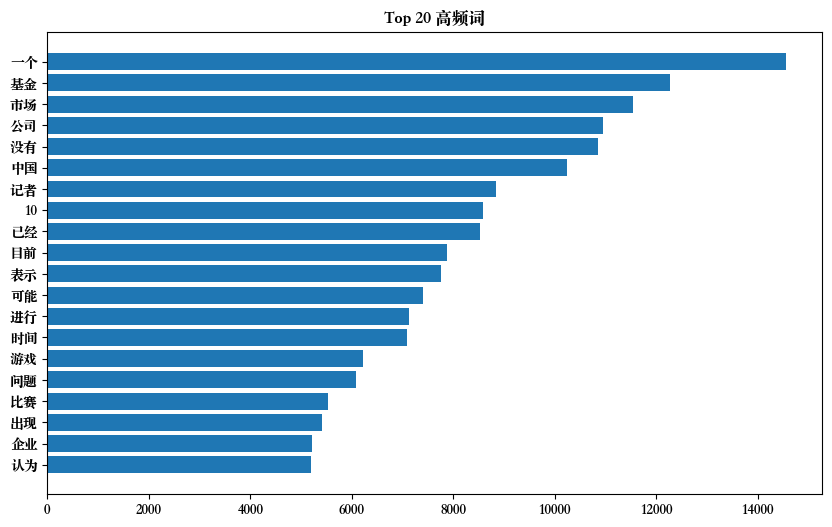

In [10]:
# 词频可视化
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(df_freq["word"][:20][::-1], df_freq["count"][:20][::-1])
plt.title("Top 20 高频词")
plt.show()
# [::-1] 是Python中列表切片的技巧，表示“反转列表”。这里使用它两次是为了让条形图从上到下按频率高低排序，看起来更符合阅读习惯。


In [11]:
df_freq.to_csv("thucnews_word_frequency.csv", index=False)


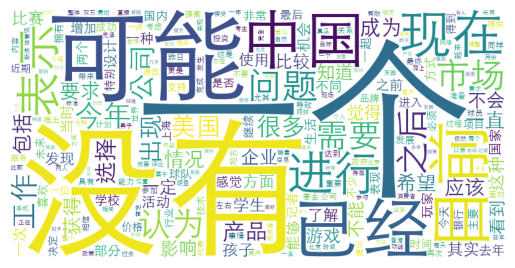

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(
    font_path="/System/Library/Fonts/STHeiti Light.ttc",  
    width=800, height=400, background_color="white",max_words=250,colormap='viridis'
).generate(" ".join(clean_words))

plt.imshow(wc)
plt.axis("off")
plt.show()
